# Create Boxplots Showing the Distribution of Generation by Month


In [1]:
# Start by importing the packages we need:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Suppress Future Warnings


In [2]:
# Suppress future warnings:
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


## Set the Directory Structure

In [3]:
# Set the data input and output directories:
hw_cs_data_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/thermal_events_data/'
gridview_data_input_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/data/gridview_results/'
image_output_dir =  '/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_tbd/figures/regional_results/'


## Plot the Generation Mix by Month


In [113]:
def plot_generation_mix(region: str, hw_cs_data_dir: str, gridview_data_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Read in the heat wave event library:
    hw_df = pd.read_csv((hw_cs_data_dir + 'hw_library_expanded.csv'))
    cs_df = pd.read_csv((hw_cs_data_dir + 'cs_library_expanded.csv'))

    # Subset to just the data for region you want to use:
    if region == 'CA':
       region_name = 'California'
       region_code = 'CA' 
       hw_df = hw_df[(hw_df['Region'] == 'CA')].copy()
       cs_df = cs_df[(cs_df['Region'] == 'CA')].copy()
    if region == 'GB':
       region_name = 'Great Basin'
       region_code = 'BS' 
       hw_df = hw_df[(hw_df['Region'] == 'GB')].copy()
       cs_df = cs_df[(cs_df['Region'] == 'GB')].copy()

    # Read in the raw data from the heat wave library:
    gen_df = pd.read_csv((gridview_data_input_dir + 'all_' + region_code + '_generation.csv'))

    # Rename the date column:
    gen_df.rename(columns={'Unnamed: 0': 'Time_UTC'}, inplace=True)
    
    # Extract the month and date for grouping:
    gen_df['Time_UTC'] = pd.to_datetime(gen_df['Time_UTC'])
    gen_df['Month'] = gen_df['Time_UTC'].dt.month
    gen_df['Date'] = gen_df['Time_UTC'].dt.date
    gen_df['Date'] = pd.to_datetime(gen_df['Date'])

    # Round off the generation values to a single decimal:
    gen_df['Coal'] = gen_df['Coal'].round(1)
    gen_df['Gas'] = gen_df['Gas'].round(1)
    gen_df['Hydro'] = gen_df['Hydro'].round(1)
    gen_df['Other'] = gen_df['Other'].round(1)
    gen_df['Solar'] = gen_df['Solar'].round(1)
    gen_df['Wind'] = gen_df['Wind'].round(1)

    # Calculate the total generation across all types and for renewable vs non-renewable:
    gen_df['Total'] = gen_df['Coal'] + gen_df['Gas'] + gen_df['Hydro'] + gen_df['Other'] + gen_df['Solar'] + gen_df['Wind']
    gen_df['Fossil'] = gen_df['Coal'] + gen_df['Gas']
    gen_df['Renewable'] = gen_df['Hydro'] + gen_df['Solar'] + gen_df['Wind']

    # Reorder the columns because I'm OCD:
    gen_df = gen_df[['Time_UTC', 'Date', 'Month', 'Total', 'Coal', 'Gas', 'Hydro', 'Solar', 'Wind', 'Other', 'Fossil', 'Renewable']]

    # Loop over rows in the heat wave event library:
    for row in range(len(hw_df)):
        # Extract the start and end dates for the event in that row:
        start_date = pd.to_datetime(hw_df['Start'].iloc[[row]].item())
        end_date = pd.to_datetime(hw_df['End'].iloc[[row]].item())

        # Subset to just the hours during that event:
        temp_df = gen_df[(gen_df['Date'] >= start_date) & (gen_df['Date'] <= end_date)]

        # Aggregate the output into a new dataframe:
        if row == 0:
           hw_gen_df = temp_df
        else:
           hw_gen_df = pd.concat([hw_gen_df, temp_df])

        # Clean up and move to the next row:
        del start_date, end_date, temp_df

    # Loop over rows in the cold snap event library:
    for row in range(len(cs_df)):
        # Extract the start and end dates for the event in that row:
        start_date = pd.to_datetime(cs_df['Start'].iloc[[row]].item())
        end_date = pd.to_datetime(cs_df['End'].iloc[[row]].item())

        # Subset to just the hours during that event:
        temp_df = gen_df[(gen_df['Date'] >= start_date) & (gen_df['Date'] <= end_date)]

        # Aggregate the output into a new dataframe:
        if row == 0:
           cs_gen_df = temp_df
        else:
           cs_gen_df = pd.concat([cs_gen_df, temp_df])

        # Clean up and move to the next row:
        del start_date, end_date, temp_df
        
    # Subset to just the daytime values for solar:
    day_gen_df = gen_df[gen_df['Solar'] != 0]
    day_hw_gen_df = hw_gen_df[hw_gen_df['Solar'] != 0]
    day_cs_gen_df = cs_gen_df[cs_gen_df['Solar'] != 0]
    
    # Make the plot:
    plt.figure(figsize=(30,30))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True
    
    ax1 = plt.subplot(511)
    plt.plot([np.nan,np.nan], color='b', linestyle='-', label='Cold Snap Days', linewidth=2)
    plt.plot([np.nan,np.nan], color='k', linestyle='-', label='All Days', linewidth=2)
    plt.plot([np.nan,np.nan], color='r', linestyle='-', label='Heat Wave Days', linewidth=2)
    for month in range(1,13):
        box1a = plt.boxplot(gen_df['Total'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box1a[item], color='k', markeredgecolor='k', linewidth=2)
        box1b = plt.boxplot(hw_gen_df['Total'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box1b[item], color='r', markeredgecolor='r', linewidth=2)   
        box1c = plt.boxplot(cs_gen_df['Total'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box1c[item], color='b', markeredgecolor='b', linewidth=2)    
    plt.legend(loc='upper left', prop={'size': 12})
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.ylabel('Hourly Generation [MWh]', fontsize=18)
    plt.title(('Total Generation in ' + region_name + ' Region'))
    plt.title('a)', loc='left', fontsize=16)

    ax2 = plt.subplot(512)
    for month in range(1,13):
        box2a = plt.boxplot(gen_df['Fossil'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box2a[item], color='k', markeredgecolor='k', linewidth=2)
        box2b = plt.boxplot(hw_gen_df['Fossil'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box2b[item], color='r', markeredgecolor='r', linewidth=2)
        box2c = plt.boxplot(cs_gen_df['Fossil'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box2c[item], color='b', markeredgecolor='b', linewidth=2)    
    plt.ylim(bottom=0)
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.ylabel('Hourly Generation [MWh]', fontsize=18)
    plt.title(('Coal + Gas'))
    plt.title('b)', loc='left', fontsize=16)

    ax3 = plt.subplot(513)
    for month in range(1,13):
        box3a = plt.boxplot(gen_df['Hydro'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box3a[item], color='k', markeredgecolor='k', linewidth=2)
        box3b = plt.boxplot(hw_gen_df['Hydro'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box3b[item], color='r', markeredgecolor='r', linewidth=2)
        box3c = plt.boxplot(cs_gen_df['Hydro'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box3c[item], color='b', markeredgecolor='b', linewidth=2)
    plt.ylim(bottom=0)
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.ylabel('Hourly Generation [MWh]', fontsize=18)
    plt.title(('Hydropower'))
    plt.title('c)', loc='left', fontsize=16)

    ax4 = plt.subplot(514)
    for month in range(1,13):
        box4a = plt.boxplot(gen_df['Wind'].loc[(gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box4a[item], color='k', markeredgecolor='k', linewidth=2)
        box4b = plt.boxplot(hw_gen_df['Wind'].loc[(hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box4b[item], color='r', markeredgecolor='r', linewidth=2)
        box4c = plt.boxplot(cs_gen_df['Wind'].loc[(cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box4c[item], color='b', markeredgecolor='b', linewidth=2)
    plt.ylim(bottom=0)
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.ylabel('Hourly Generation [MWh]', fontsize=18)
    plt.title(('Wind'))
    plt.title('d)', loc='left', fontsize=16)
    
    ax5 = plt.subplot(515)
    for month in range(1,13):
        box5a = plt.boxplot(day_gen_df['Solar'].loc[(day_gen_df['Month']==month)], vert=True, positions=[month], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box5a[item], color='k', markeredgecolor='k', linewidth=2)
        box5b = plt.boxplot(day_hw_gen_df['Solar'].loc[(day_hw_gen_df['Month']==month)], vert=True, positions=[month+0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box5b[item], color='r', markeredgecolor='r', linewidth=2)
        box5c = plt.boxplot(day_cs_gen_df['Solar'].loc[(day_cs_gen_df['Month']==month)], vert=True, positions=[month-0.2], widths=0.2)
        for item in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box5c[item], color='b', markeredgecolor='r', linewidth=2)    
    plt.ylim(bottom=0)
    plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.ylabel('Hourly Generation [MWh]', fontsize=18)
    plt.title(('Solar (Daytime Values Only)'))
    plt.title('e)', loc='left', fontsize=16)

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir + region + '_Annual_Generation.png'), dpi=image_resolution, bbox_inches='tight')
       #plt.close()

    return day_cs_gen_df


,Time_UTC,Date,Month,Total,Coal,Gas,Hydro,Solar,Wind,Other,Fossil,Renewable
31,1982-01-02 07:00:00,1982-01-02,1,25236.7,55.0,13528.3,4511.6,86.0,1494.1,5561.7,13583.3,6091.7
32,1982-01-02 08:00:00,1982-01-02,1,33655.4,55.0,12144.9,4193.0,10679.1,1312.2,5271.2,12199.9,16184.3
33,1982-01-02 09:00:00,1982-01-02,1,36153.9,55.0,6115.7,3844.4,20912.4,1192.0,4034.4,6170.7,25948.8
34,1982-01-02 10:00:00,1982-01-02,1,39551.6,27.5,4463.9,3650.4,26712.2,1131.3,3566.3,4491.4,31493.9
35,1982-01-02 11:00:00,1982-01-02,1,41975.3,27.5,3542.0,3509.6,30356.9,1135.5,3403.8,3569.5,35002.0
...,...,...,...,...,...,...,...,...,...,...,...,...
332125,2019-11-30 13:00:00,2019-11-30,11,40431.6,0.0,4183.4,1791.2,30058.2,1182.9,3215.9,4183.4,33032.3
332126,2019-11-30 14:00:00,2019-11-30,11,36863.9,0.0,4093.4,1840.9,25882.7,1181.4,3865.5,4093.4,28905.0
332127,2019-11-30 15:00:00,2019-11-30,11,35709.8,0.0,6147.6,1984.3,20958.7,1211.8,5407.4,6147.6,24154.8
332128,2019-11-30 16:00:00,2019-11-30,11,30496.4,0.0,8567.0,2355.2,10901.6,1282.8,7389.8,8567.0,14539.6


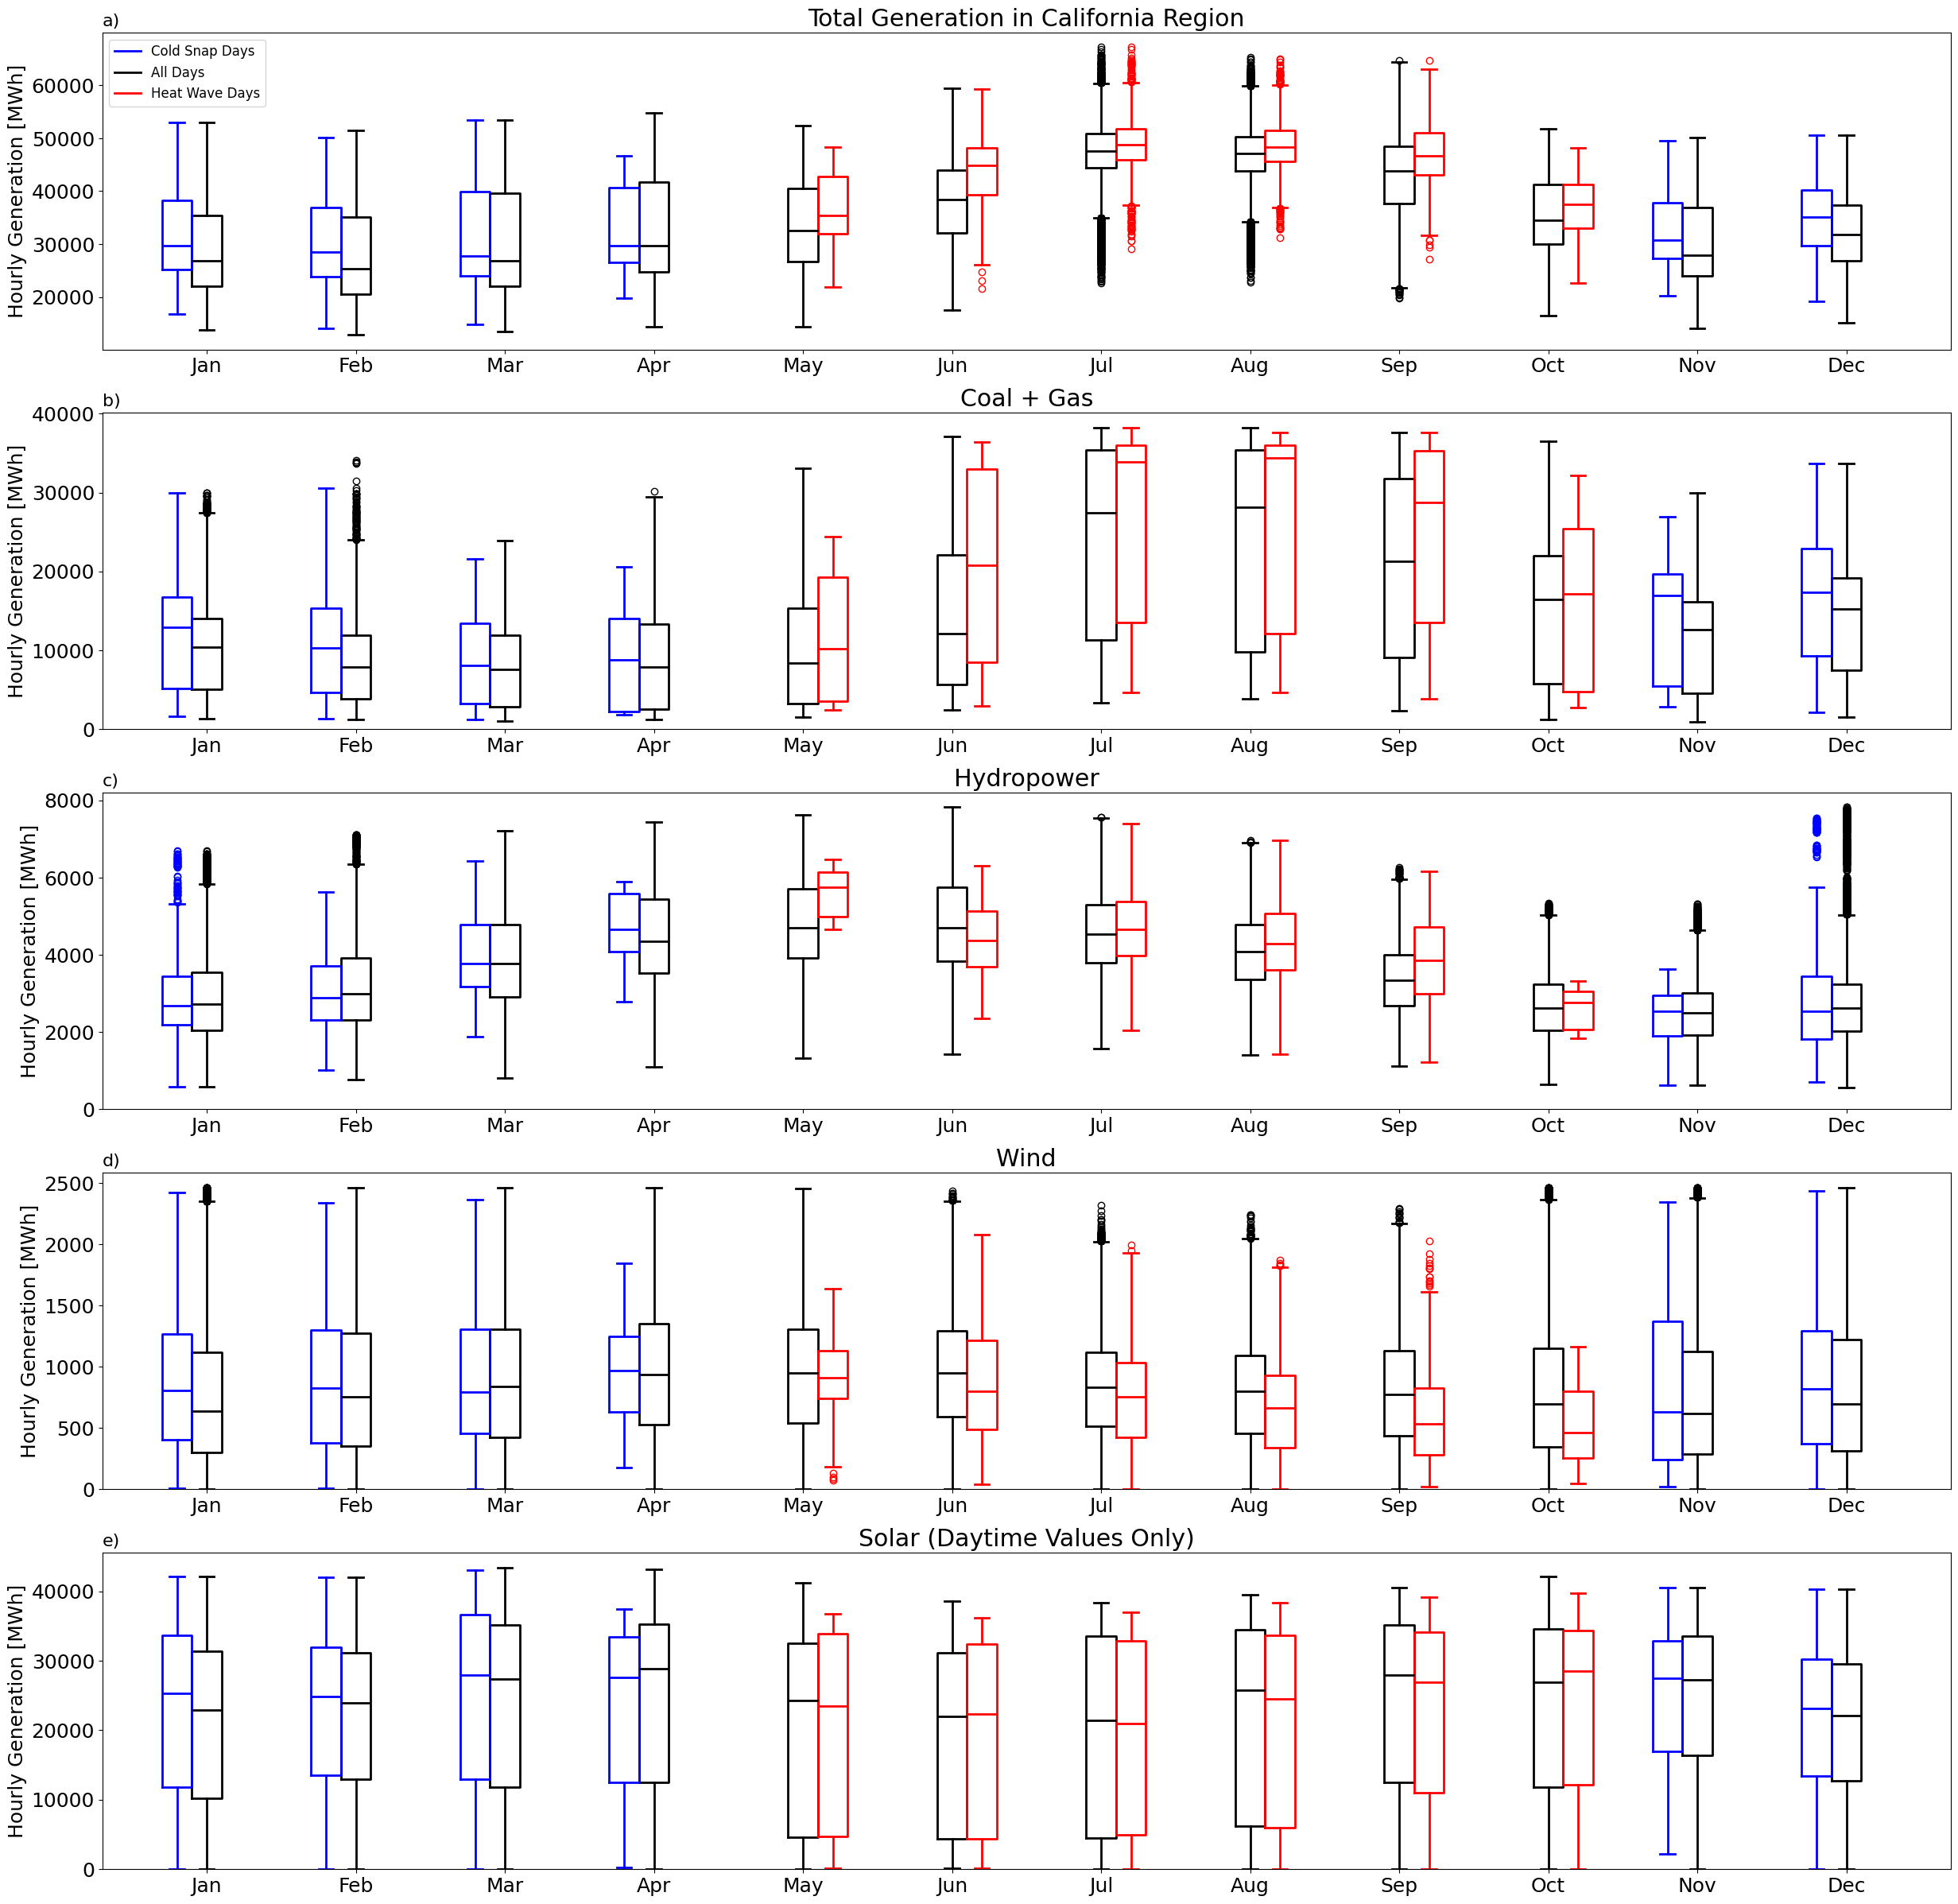

In [115]:
# Test the function:
output_df = plot_generation_mix(region = 'CA',
                                hw_cs_data_dir = hw_cs_data_dir,
                                gridview_data_input_dir = gridview_data_input_dir,
                                image_output_dir = image_output_dir, 
                                image_resolution = 150,
                                save_images = True)

output_df
